In [2]:
import tensorflow as tf
import numpy as np

print(f'현재 텐서플로우 버전은? {tf.__version__}')

현재 텐서플로우 버전은? 2.20.0


# 텐서플로우 기초

In [3]:
a = tf.constant(2) # 텐서를 선언합니다.
b = tf.constant([1, 2])
c = tf.constant([[1, 2], [3, 4]])

print(tf.rank(a)) # 텐서의 랭크를 계산합니다.
print(tf.rank(b))
print(tf.rank(c))

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)


In [4]:
a = tf.constant(3)
b = tf.constant(2)

print(tf.add(a, b)) # 더하기
print(tf.subtract(a, b)) # 빼기

# numpy 이용해서 계산하면 일반적인 numpy 형식으로 나옴
print(tf.multiply(a, b).numpy()) # 곱하기
print(tf.divide(a, b).numpy()) # 나누기

tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
6
1.5


In [5]:
type(tf.multiply(a, b).numpy())

numpy.int32

In [6]:
type(tf.divide(a,b).numpy())

numpy.float64

In [7]:
c = tf.add(a, b).numpy() # a와 b를 더한 후 NumPy 배열 형태로 변환합니다.
c_square = np.square(c, dtype = np.float32) # NumPy 모듈에 존재하는 square(제곱) 함수를 적용합니다.
c_tensor = tf.convert_to_tensor(c_square) # 다시 텐서로 변환해줍니다.

# 넘파이 배열과 텐서 각각을 확인하기 위해 출력합니다.
print(f'numpy array : {c}, applying square with numpy : {c_square}, convert_to_tensor : {c_tensor}')

numpy array : 5, applying square with numpy : 25.0, convert_to_tensor : 25.0


In [8]:
type(c_square)

numpy.float32

In [9]:
type(c_tensor)

tensorflow.python.framework.ops.EagerTensor

# 단층 퍼셉트론

In [10]:
import numpy as np
import tensorflow as tf

# 모델을 쌓기 위한 라이브러리
from tensorflow.keras.models import Sequential

# Dense = 층 1개
from tensorflow.keras.layers import Dense

from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import mse

tf.random.set_seed(777)

# 데이터 준비하기
data = np.array([[0,0], [0,1], [1,0], [1,1]])
label = np.array([[0], [1], [1], [1]])

# 모델 구성하기
model = Sequential()

# 단층 퍼셉트론 추가
model.add(Dense(1, input_shape=(2, ), activation = 'linear'))

# 모델 준비하기 - list 형식으로 평가지표 전달
model.compile(optimizer = SGD(), loss = mse, metrics = ['acc'])

# 모델 학습시키기
model.fit(data, label, epochs = 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step - acc: 0.7500 - loss: 0.2838
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7500 - loss: 0.2817
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7500 - loss: 0.2796
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7500 - loss: 0.2775
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.7500 - loss: 0.2755
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - acc: 0.7500 - loss: 0.2734
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - acc: 0.7500 - loss: 0.2714
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - acc: 0.7500 - loss: 0.2694
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - acc: 0.7500 - loss: 0.2674
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.7500 - loss: 0.2655
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.7500 - loss: 0.2635
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - acc: 0.7500 - loss: 0.2616
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140m

In [11]:
model.get_weights()  # 모델 가중치 확인하기

[array([[0.3801184 ],
        [0.84208727]], dtype=float32),
 array([0.11820897], dtype=float32)]

In [12]:
# evaluate(): 평가를 진행합니다
model.evaluate(data, label)

# predict(): 예측을 진행합니다.
preds = model.predict(data)
for a, b in zip(preds, label):
    print(f"예측값 {a} - 정답 {b}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - acc: 0.7500 - loss: 0.0958
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
예측값 [0.11820897] - 정답 [0]
예측값 [0.9602962] - 정답 [1]
예측값 [0.49832737] - 정답 [1]
예측값 [1.3404146] - 정답 [1]


# XOR 문제와 다층 퍼셉트론

In [13]:
# 내적 해보기
import tensorflow as tf

# uniform 분포에서 해당 크기만큼 난수를 생성합니다.
x = tf.random.uniform((10, 5))
w = tf.random.uniform((5, 3))
d = tf.matmul(x, w) # (10, 5) * (5, 3) -> (10, 3)

print(f'x와 w의 벡터 내적 결과 크기:{d.shape}')

x와 w의 벡터 내적 결과 크기:(10, 3)


In [14]:
# XOR 문제 - 실패 (단층 퍼셉트론)

import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import mse

tf.random.set_seed(777) # 시드를 설정합니다.

# 데이터 준비하기
x = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# 모델 구성하기
model = Sequential()
# 단층 퍼셉트론을 구성합니다.
model.add(Dense(1, input_shape = (2, ), activation = 'linear'))

# 모델 준비하기
model.compile(optimizer = SGD(),
              loss = mse,
              metrics = ['acc']) # list 형태로 평가지표를 전달합니다.

model.fit(x, y, epochs = 200)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - acc: 0.5000 - loss: 0.7796
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.5000 - loss: 0.7661
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.5000 - loss: 0.7533
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.5000 - loss: 0.7411
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.5000 - loss: 0.7296
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.5000 - loss: 0.7186
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5000 - loss: 0.7081
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5000 - loss: 0.6982
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - acc: 0.5000 - loss: 0.6888
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.5000 - loss: 0.6798
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5000 - loss: 0.6712
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - acc: 0.5000 - loss: 0.6630
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/s

In [15]:
# evaluate(): 평가를 진행합니다
model.evaluate(x, y)

# predict(): 예측을 진행합니다.
preds = model.predict(x)
for a, b in zip(preds, y):
    print(f"예측값 {a} - 정답 {b}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - acc: 0.5000 - loss: 0.3304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
예측값 [0.09977403] - 정답 [0]
예측값 [0.6346084] - 정답 [1]
예측값 [0.24088809] - 정답 [1]
예측값 [0.7757225] - 정답 [0]


In [16]:
# XOR 문제 - 성공
# 다층 퍼셉트론
import tensorflow as tf
tf.random.set_seed(777)

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import mse

# 데이터 준비하기
data = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
label = np.array([[0], [1], [1], [0]])

# 모델 구성하기 - Dense 층 2개 / ReLU + Sigmoid 활용
# input(2차원) -> (2 x 32) -> (32 x 1) -> output(1차원)
model = Sequential()
model.add(Dense(32, input_shape = (2, ), activation = 'relu'))
# model.add(Dense(16, input_shape = (2, ), activation = 'tanh'))
# model.add(Dense(32, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid')) # 최종 활성함수 sigmoid로 변경

# 모델 준비하기
model.compile(optimizer = RMSprop(), loss = mse, metrics = ['acc'])

# 학습시키기
model.fit(data, label, epochs = 200)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step - acc: 0.5000 - loss: 0.2749
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - acc: 0.2500 - loss: 0.2725
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.2500 - loss: 0.2706
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.2500 - loss: 0.2692
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.5000 - loss: 0.2680
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.5000 - loss: 0.2669
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.5000 - loss: 0.2659
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.5000 - loss: 0.2650
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5000 - loss: 0.2641
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - acc: 0.5000 - loss: 0.2633
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - acc: 0.5000 - loss: 0.2625
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.5000 - loss: 0.2617
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/s

In [17]:
model.evaluate(data, label)
result = model.predict(data)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - acc: 1.0000 - loss: 0.1709
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[[0.46389502]
 [0.6035507 ]
 [0.6053825 ]
 [0.3941417 ]]


# Activation Function

In [18]:
# sigmoid 함수 그리기
import numpy as np
import matplotlib.pyplot as plt
import math

# 시그모이드 함수
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 하이퍼볼릭탄젠트 함수
def tanh(x):
    return list(map(lambda x : math.tanh(x), x))
# lambda, map : https://wikidocs.net/64
#

# relu 함수
def relu(x):
    result = []
    for ele in x:
        if(ele <= 0):
            result.append(0)
        else:
            result.append(ele)

    return result

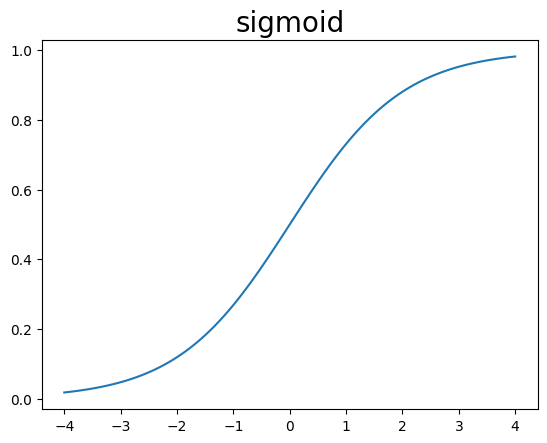

In [19]:
# 시그모이드 함수 그려보기
x = np.linspace(-4, 4, 100)
sig = sigmoid(x)

plt.plot(x, sig); plt.title('sigmoid', fontsize = 20)
plt.show()

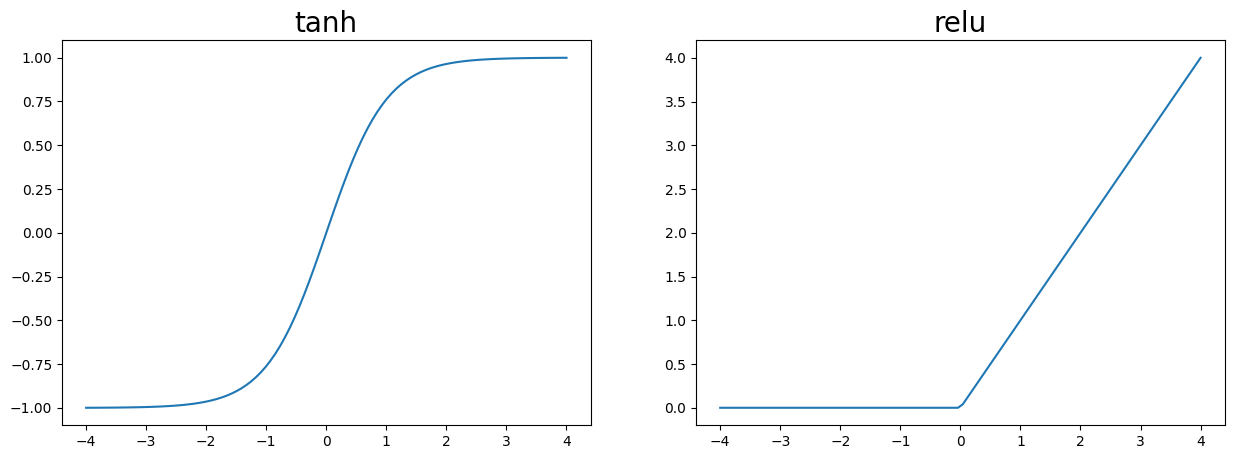

In [20]:
x = np.linspace(-4, 4, 100)
tan_h = tanh(x)
relu_d = relu(x)

plt.figure(figsize = (15, 5))
plt.subplot(1, 2, 1)
plt.plot(x, tan_h); plt.title('tanh', fontsize = 20)
plt.subplot(1, 2, 2)
plt.plot(x, relu_d); plt.title('relu', fontsize = 20)

plt.show()

# 경사하강법

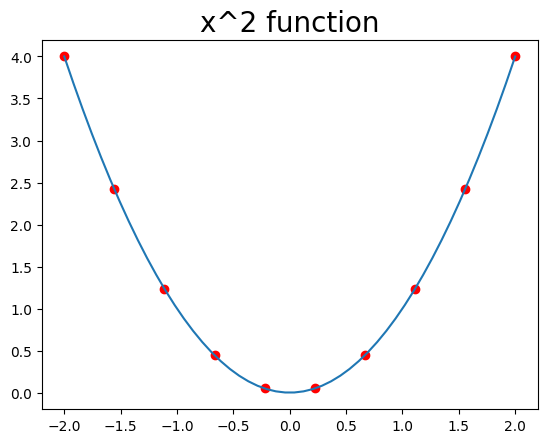

In [21]:
# 경사하강법 확인해보기
# np.linspace(): 1차원의 배열 만들기
x = np.linspace(-2, 2, 50)
x_square = [i ** 2 for i in x]

x_2 = np.linspace(-2, 2, 10)
dev_x = [i ** 2 for i in x_2]

plt.title('x^2 function', fontsize = 20)
plt.plot(x, x_square)
fig = plt.scatter(x_2, dev_x, color = 'red')
plt.show()

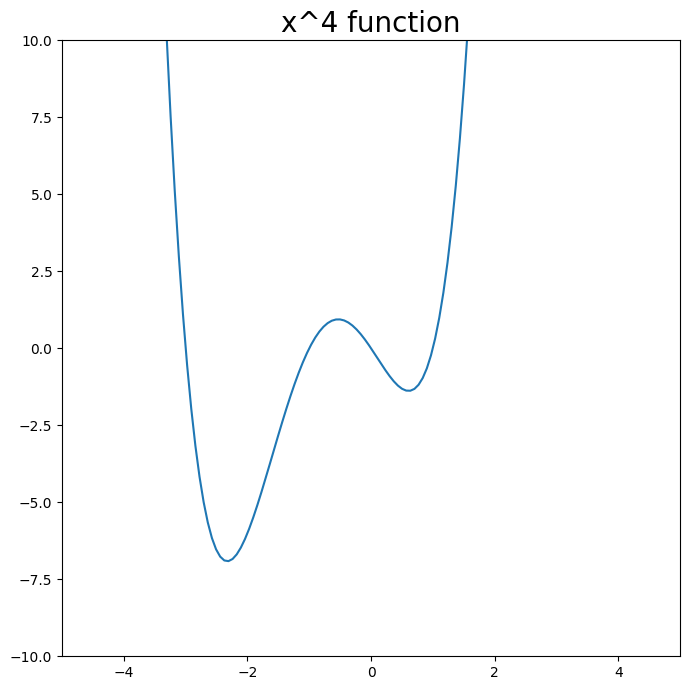

In [22]:
x = np.linspace(-10, 10, 300)
four_func = [(i)*(i - 1)*(i + 1)*(i + 3) for i in x]

fig = plt.figure(figsize = (7, 7))
plt.title('x^4 function', fontsize = 20)
plt.plot(x, four_func)
plt.xlim(-5, 5)
plt.ylim(-10, 10)
frame1 = plt.gca()
plt.tight_layout() #  서브 플롯 크기 또는 간격을 개선하기 위해 Matplotlib에서 서브 플롯 크기를 개선
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def get_derivative(lr):

    w_old = 2
    derivative = [w_old]

    y = [w_old ** 2] # 손실 함수를 y= x^2 로 정의합니다.

    for i in range(1, 10):
        # 먼저 해당 위치에서 미분값을 구합니다.
        dev_value = w_old * 2

        # 위의 값을 이용하여 가중치를 업데이트합니다.
        w_new = w_old - lr * dev_value
        w_old = w_new

        derivative.append(w_old) # 업데이트 된 가중치를 저장합니다.
        y.append(w_old ** 2) # 업데이트 된 가중치의 손실값을 저장합니다.

    return derivative, y

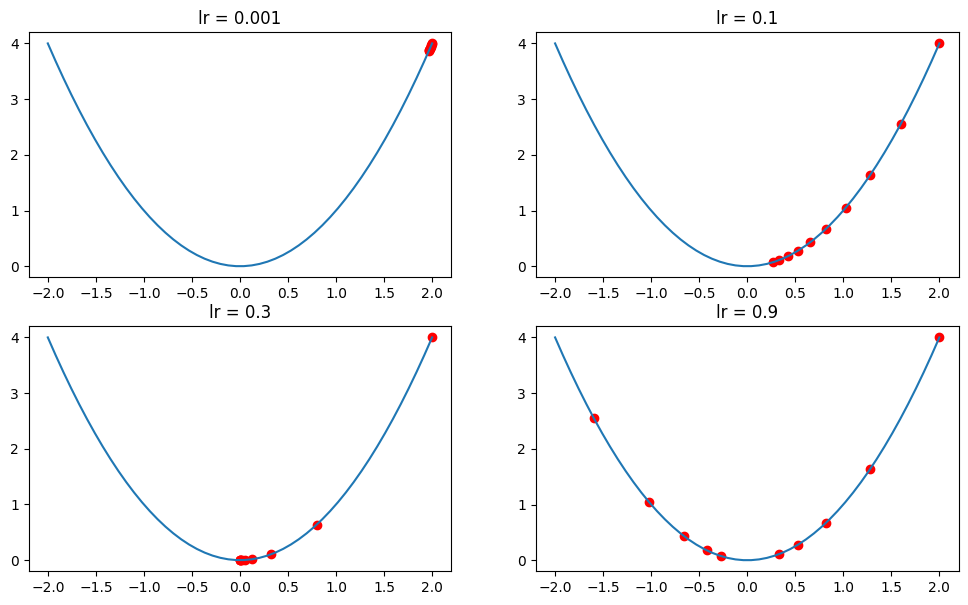

In [24]:
# 여러 가지 학습률을 사용하여 값의 변화를 관찰해보도록 합니다.
lr_list = [0.001, 0.1, 0.3, 0.9]

x = np.linspace(-2, 2, 50) # -2 ~ 2의 범위를 50구간으로 나눈 배열을 반환합니다.
x_square = [i ** 2 for i in x]

fig = plt.figure(figsize = (12, 7))

for i, lr in enumerate(lr_list):
    derivative, y = get_derivative(lr)
    ax = fig.add_subplot(2, 2, i + 1)
    ax.scatter(derivative, y, color = 'red')
    ax.plot(x, x_square)
    ax.title.set_text('lr = ' + str(lr))

plt.show()

# MNIST

In [75]:
from tensorflow.keras.datasets import mnist
data= mnist.load_data()
len(data[0][0]), len(data[1][0])

(60000, 10000)

In [76]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [77]:
# 훈련 데이터
print(x_train.shape, y_train.shape)
print(y_train[:10])

# 테스트 데이터
print(x_test.shape, y_test.shape)
print(y_test[:10])

(60000, 28, 28) (60000,)
[5 0 4 1 9 2 1 3 1 4]
(10000, 28, 28) (10000,)
[7 2 1 0 4 1 4 9 5 9]


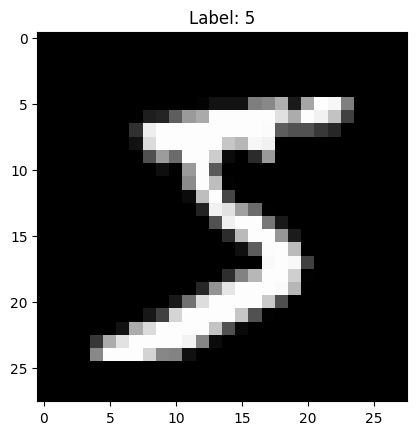

In [78]:
# 이미지 출력
import matplotlib.pyplot as plt

img = x_train[0]
label = y_train[0]

plt.figure()
plt.imshow(img, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [79]:
for i in x_test[0]:
  for j in i:
    print(f'{j:4}', end='')
  print('\n')

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 198 198 170  52

# MNIST 데이터셋 분리

In [80]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                  test_size=0.2,
                                                  random_state=42)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_train[0])

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0  17  47  47  47  47  47  47  28   0]
 [  0   0   0   0   0   0   0   0   0  14  63   0   0   0  62 138 197 197
  197 217 253 253 253 253 253 253 230   0]
 [  0   0   0   0   0   0   0   0   0 151 170   0  56 232 250 253 231 217
  217 217 217 217 217 217 128 179 132   0]
 [  0   0   0 

# 데이터 전처리

In [81]:
# 데이터 갯수
num_x_train = x_train.shape[0]
num_x_val = x_val.shape[0]
num_x_test = x_test.shape[0]

# 데이터 전처리(MinMax 적용)
x_train = (x_train.reshape((num_x_train, 28*28))) / 255
x_val = (x_val.reshape((num_x_val, 28*28))) / 255
x_test = (x_test.reshape((num_x_test, 28*28))) / 255

# 40000개 짜리 Data / 1차원
print(x_train.shape)

(48000, 784)


In [82]:
print(x_train[0])

[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.       

# Label 전처리 - One-Hot Encoding

In [83]:
from tensorflow.keras.utils import to_categorical  # 원핫-인코딩

# 범주형 형식으로 변경
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

# 모델 생성

In [84]:
import numpy as np

# 소프트맥스 함수
def softmax(arr):
  max_arr = np.max(arr)
  arr = arr - max_arr # 오버플로우 방지
  arr = np.exp(arr)   # 자연로그 적용
  return arr / np.sum(arr)

# 시그모이드 함수
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

case_1 = np.array([3.1, 3.0, 2.9])
case_2 = np.array([2.0, 1.0, 0.7])

np.set_printoptions(precision=3) # numpy 소수점 제한
print(f'sigmoid {sigmoid(case_1)}, softmax {softmax(case_1)}')
print(f'sigmoid {sigmoid(case_2)}, softmax {softmax(case_2)}')
print(x_train[0].shape)

sigmoid [0.957 0.953 0.948], softmax [0.367 0.332 0.301]
sigmoid [0.881 0.731 0.668], softmax [0.61  0.224 0.166]
(784,)


In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation='relu', input_shape = (784, )))
# => 784차원의 데이터 입력 => 64개의 출력값 생성
model.add(Dense(128, activation='relu')) # 입력: 64개, 출력:128
model.add(Dense(32, activation='relu')) # 입력: 128개, 출력:32
model.add(Dense(32, activation='relu')) # 입력: 32개, 출력:32
model.add(Dense(10, activation='softmax')) # 최종 10개의 출력

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.compile(optimizer='adam',   # 옵티마이져(adam: 스탭+방향)
              loss = 'categorical_crossentropy', # 손실함수
              metrics = ['acc'])  # 모니터리 평가 지표: 정확도


In [87]:
from sklearn.utils.validation import validate_data

history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=128,
                    validation_data=(x_val, y_val))

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8493 - loss: 0.4838 - val_acc: 0.9383 - val_loss: 0.2064
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9499 - loss: 0.1724 - val_acc: 0.9545 - val_loss: 0.1545
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9622 - loss: 0.1283 - val_acc: 0.9595 - val_loss: 0.1315
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9704 - loss: 0.1020 - val_acc: 0.9628 - val_loss: 0.1258
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9758 - loss: 0.0849 - val_acc: 0.9671 - val_loss: 0.1199
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9792 - loss: 0.0711 - val_acc: 0.9658 - val_loss: 0.1168
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9819 - loss: 0.0599 - val_acc: 0.9690 - val_loss: 0.1147
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9848 - loss: 0.0507 - val_acc: 0.9674 - val_loss: 0.1190
Epoch 9/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - ac

# 학습 그림 그리기

In [88]:
print(history.history)
print(history.history.keys())

{'acc': [0.8493333458900452, 0.9498958587646484, 0.9621666669845581, 0.9703541398048401, 0.9757708311080933, 0.9791874885559082, 0.9819166660308838, 0.9848124980926514, 0.9866458177566528, 0.989062488079071, 0.9888333082199097, 0.9900624752044678, 0.9911666512489319, 0.992229163646698, 0.9927083253860474, 0.9928749799728394, 0.9927291870117188, 0.9939374923706055, 0.9948333501815796, 0.9950833320617676, 0.9949791431427002, 0.9950000047683716, 0.9962083101272583, 0.995145857334137, 0.9966041445732117, 0.9956250190734863, 0.9956458210945129, 0.9965624809265137, 0.9972916841506958, 0.997041642665863], 'loss': [0.4837796092033386, 0.17240138351917267, 0.1283269077539444, 0.10197902470827103, 0.08490191400051117, 0.0710841715335846, 0.059922974556684494, 0.05071127787232399, 0.04443175345659256, 0.03780487924814224, 0.03484499454498291, 0.03164863958954811, 0.027437036857008934, 0.0240525733679533, 0.021732622757554054, 0.021253405138850212, 0.0210246779024601, 0.018108749762177467, 0.01567

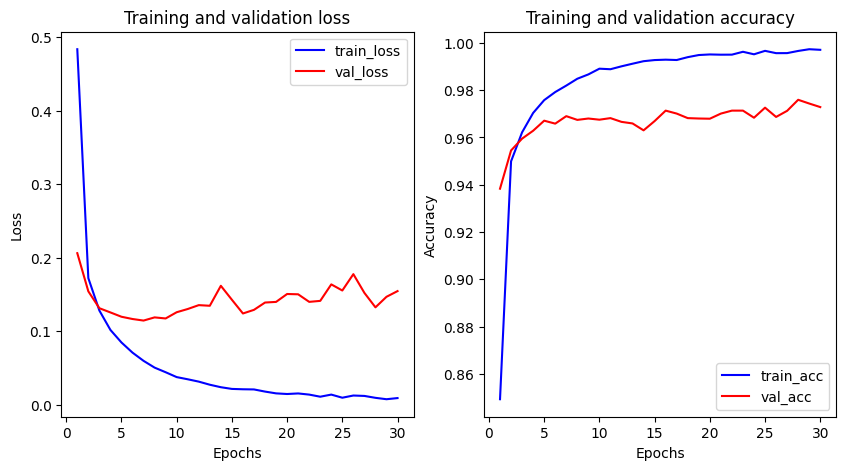

In [89]:
import matplotlib.pyplot as plt

his_dict = history.history

loss = his_dict['loss']          # 학습 데이터에 대한 loss
val_loss = his_dict['val_loss']  # 검증 데이터에 대한 loss

epochs = range(1, len(loss) + 1)

fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그래프
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='train_loss')
ax1.plot(epochs, val_loss, color='red', label='val_loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# 훈련 및 검증 정확도 그래프
acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color='blue', label='train_acc')
ax2.plot(epochs, val_acc, color='red', label='val_acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# 화면 출력
plt.show()



# 모델 평가

In [90]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Loss : {test_loss}\nAccuracy : {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9730 - loss: 0.1662
Loss : 0.16616053879261017
Accuracy : 0.9729999899864197


In [91]:
import numpy as np

np.set_printoptions(precision=7)  # 소수점 제안

y_pred = model.predict(x_test)

print(y_pred.shape)
print()
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)

[3.4762730e-14 2.9936842e-10 1.9819490e-10 5.3586096e-09 3.3302415e-15
 3.1025508e-12 3.8872652e-19 1.0000000e+00 4.7129252e-14 2.4741169e-08]


# 예측값 인식 / 그리기

In [92]:
# 예측값 중 가장 큰 값의 위치(index)를 가져와 출력
arg_result = np.argmax(y_pred, axis=1)
print(arg_result)

[7 2 1 ... 4 5 6]


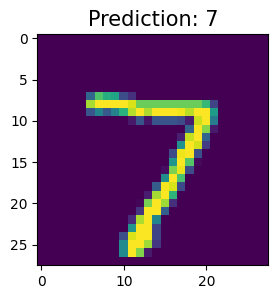

In [93]:
# 그래프로 그리기
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
plt.imshow(x_test[0].reshape(28, 28))
plt.title(f'Prediction: {arg_result[0]}', fontsize=15)
plt.show()

# 모델 평가 방법

## (1) 혼동행렬

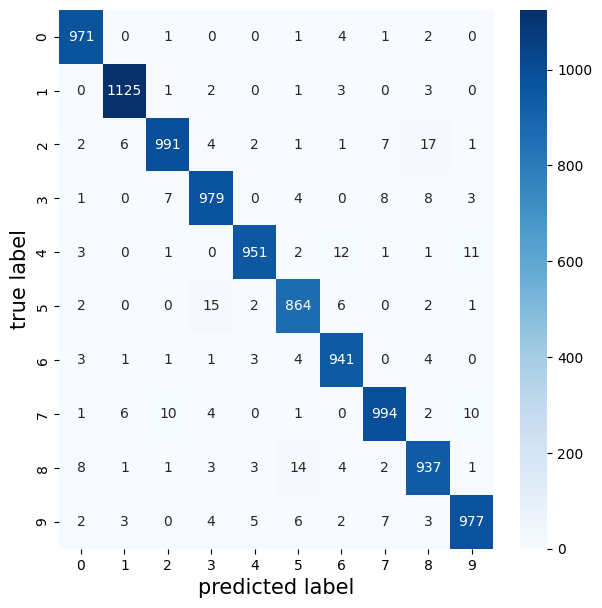

In [94]:
# sklearn.metrics 모듈은 여러가지 평가 지표에 관한 기능을 제공합니다.
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 혼동 행렬을 만듭니다.
plt.figure(figsize = (7, 7))
cm = confusion_matrix(np.argmax(y_test, axis = -1), np.argmax(y_pred, axis = -1))
sns.heatmap(cm, annot = True, fmt = 'd',cmap = 'Blues')
plt.xlabel('predicted label', fontsize = 15)
plt.ylabel('true label', fontsize = 15)
plt.show()

## (2) 모델 보고서

In [95]:
print(classification_report(np.argmax(y_test, axis = -1), np.argmax(y_pred, axis = -1)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.96      0.97      0.97       892
           6       0.97      0.98      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



# 사용자 손글씨 적용해보기

TypeError: Image data of dtype object cannot be converted to float

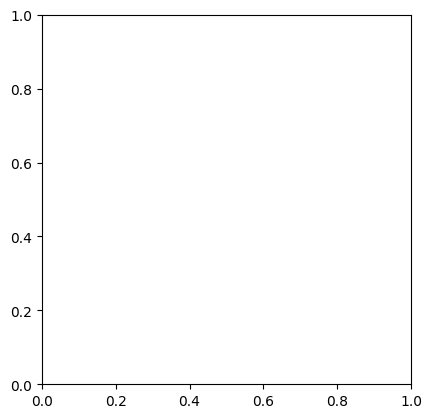

In [96]:
import cv2

img = cv2.imread('./userNum1.jpg', cv2.IMREAD_GRAYSCALE)
print(img.shape)
print(img[0])

plt.imshow(img)
plt.show()

In [99]:
img_minmax = img / 255
print(img_minmax[0])
plt.imshow(img_minmax)
plt.show()

TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'

In [100]:
img_input = img_minmax.reshape(1, 28*28)
print(img_input.shape)

NameError: name 'img_minmax' is not defined

In [101]:
userPred = model.predict(img_input)
print(userPred)
print(np.argmax(userPred))

NameError: name 'img_input' is not defined

# 모델 저장

In [97]:
# model.save('./my_mnist_model.h5')
model.save('./my_mnist_model.keras')

In [98]:
from tensorflow.keras.models import load_model

# new_model = load_model('./my_mnist_model.h5')
new_model = load_model('./my_mnist_model.keras')

new_userNum = new_model.predict(img_input)
print(np.argmax(new_userNum))

NameError: name 'img_input' is not defined